>>> 正在生成: 各风格总分分布图 (Score Distribution)...


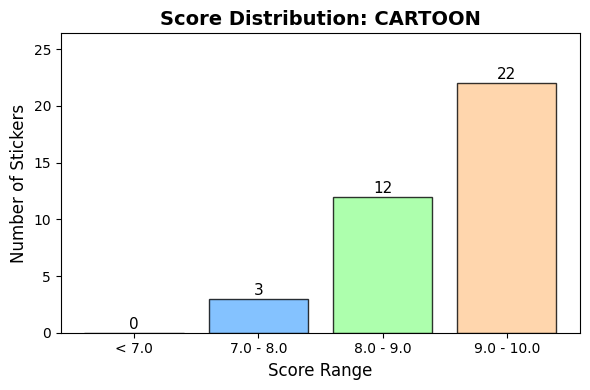

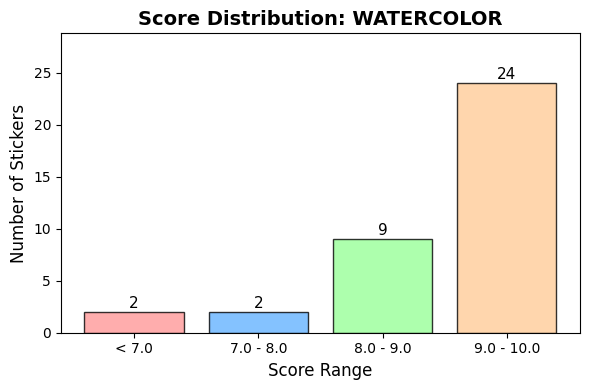

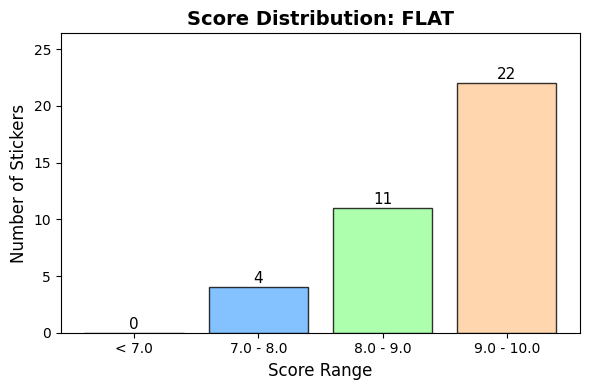


>>> 正在生成: 各风格各项维度平均分对比图 (Average Scores Comparison)...


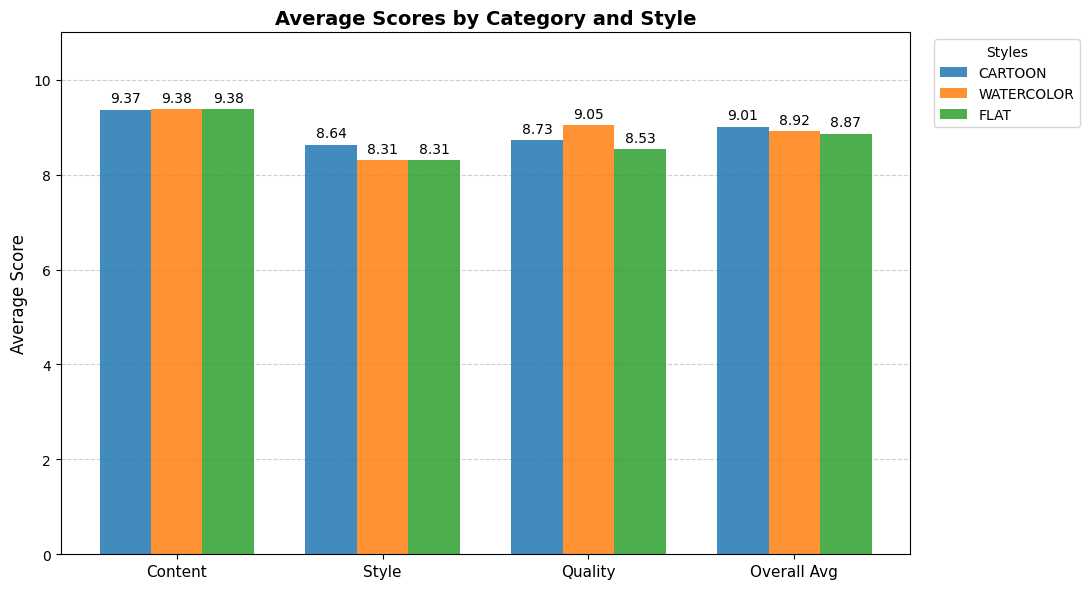


>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...


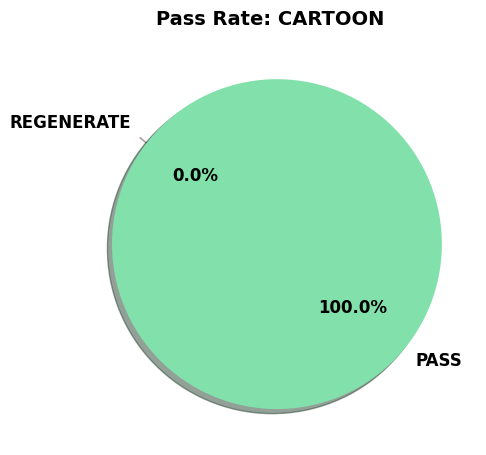

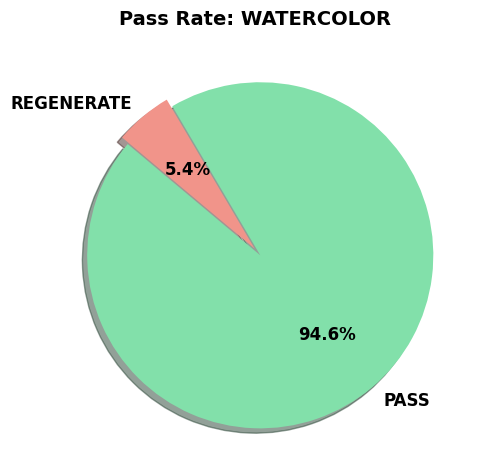

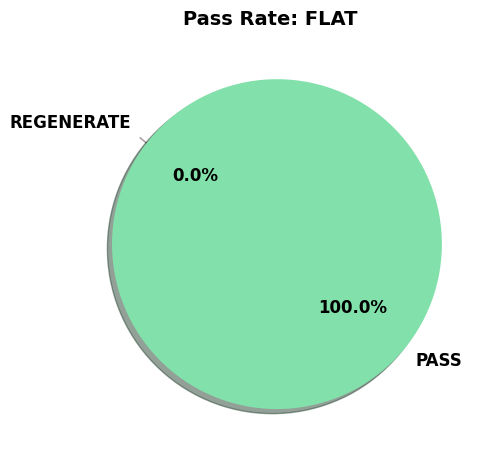

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 加载数据
# ==========================================
FILE_PATH = 'sticker_individual_scores.json'

with open(FILE_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

styles = list(data.keys())

# ==========================================
# 2. 分数段分布图
# ==========================================
print(">>> 正在生成: 各风格总分分布图 (Score Distribution)...")
for style in styles:
    scores = [item['metrics']['sticker_average_score'] for item in data[style]]

    # 初始化统计字典
    bins = {"< 7.0": 0, "7.0 - 8.0": 0, "8.0 - 9.0": 0, "9.0 - 10.0": 0}
    for s in scores:
        if s < 7.0: bins["< 7.0"] += 1
        elif 7.0 <= s < 8.0: bins["7.0 - 8.0"] += 1
        elif 8.0 <= s < 9.0: bins["8.0 - 9.0"] += 1
        else: bins["9.0 - 10.0"] += 1

    # 绘图
    plt.figure(figsize=(6, 4))
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
    bars = plt.bar(bins.keys(), bins.values(), color=colors, edgecolor='black', alpha=0.8)

    plt.title(f'Score Distribution: {style.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Score Range', fontsize=12)
    plt.ylabel('Number of Stickers', fontsize=12)

    # 在柱子上添加具体数字
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=11)

    plt.ylim(0, max(bins.values()) * 1.2 if max(bins.values()) > 0 else 10)
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. 各项评分的均值对比图
# ==========================================
print("\n>>> 正在生成: 各风格各项维度平均分对比图 (Average Scores Comparison)...")
metrics = ['content_score', 'style_score', 'quality_score', 'sticker_average_score']
labels = ['Content', 'Style', 'Quality', 'Overall Avg']

# 计算均值
means = {style: [] for style in styles}
for style in styles:
    for metric in metrics:
        vals = [item['metrics'][metric] for item in data[style]]
        mean_val = np.mean(vals) if vals else 0
        means[style].append(mean_val)

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 6))

# 动态绘制分组柱状图
for i, style in enumerate(styles):
    offset = (i - len(styles)/2 + 0.5) * width
    bars = ax.bar(x + offset, means[style], width, label=style.upper(), alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)

ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Scores by Category and Style', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(title="Styles", bbox_to_anchor=(1.02, 1), loc='upper left')

ax.set_ylim(0, 11)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PASS 与 REGENERATE 比例饼图
# ==========================================
print("\n>>> 正在生成: 审核通过率饼图 (Pass vs Regenerate Ratio)...")
for style in styles:
    statuses = [item['metrics']['status'] for item in data[style]]
    pass_count = statuses.count('PASS')
    regen_count = statuses.count('REGENERATE')

    sizes = [pass_count, regen_count]
    labels = ['PASS', 'REGENERATE']
    colors = ['#82E0AA', '#F1948A'] # 绿色代表PASS，红色代表REGENERATE
    explode = (0.05, 0) # 让 PASS 的扇区稍微分离一点

    if sum(sizes) == 0:
        print(f"[{style.upper()}] 没有数据，跳过饼图。")
        continue

    plt.figure(figsize=(5, 5))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=140,
            textprops={'fontsize': 12, 'fontweight': 'bold'})

    plt.title(f'Pass Rate: {style.upper()}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()